In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Salting in, salting out, and a precipitation temperature that is really a glass transition (Figures 15.2-1 and 15.2-3)

$$M_{P,s}=M_{P,ns}\exp\!\left[\frac{1.178\,|z_+z_-|\sqrt{I_s}}{1+A\sqrt{I_s}}+k_sI_s\right]$$

Section 15.2 has two halves and they are two different equations.

**(a) Ionic strength.** Eq. 15.2-11 is a *competition*: a Debye-Huckel term that always raises
solubility, growing as $\sqrt{I}$, against a dielectric-decrement term that usually lowers it,
growing as $I$. Whichever wins at small $I$ loses at large $I$, so the model can produce a
solubility that rises and then falls — which is exactly what Green's carboxyhemoglobin data do for
two of three salts.

**(b) Temperature.** Eqs. 15.2-14 to 15.2-16 are the *freezing-point* equation of Sec. 12.3 wearing
different labels: solid-to-liquid becomes amorphous-to-solution, and the melting point becomes the
temperature at which a drug first precipitates out of a formulation. `thermo.sle.freezing_point`
solves it already, so half (b) needs no new machinery at all — only the two materials' calorimetry.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.insert(0, "..")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from thermo.charts import use_book_style
from thermo.sle import freezing_point, ln_x_gamma
from thermo.sle import R as R_SLE      # CODATA; the book's arithmetic uses 8.314

use_book_style()
os.makedirs("pdf", exist_ok=True)

R = 8.314
T25 = 298.15
B_WATER = 1.178          # Eq. 15.2-4, pure water at 25 C
FIG_W = 3.4

## (a) The competition, written down

Eq. 15.2-9 splits $\ln\gamma_\pm$ into two pieces of different sign and different power of $I$:

$$\ln\gamma_{\pm,s}=-\frac{1.178\,|z_+z_-|\sqrt{I}}{1+A\sqrt{I}}-\beta\delta_sI,
\qquad k_s\equiv\beta\delta_s$$

and Eq. 15.2-3 turns $-\ln\gamma_\pm$ into the solubility ratio. The dielectric increment $\delta_s$
is *negative* for most inorganic salts (they lower the dielectric constant of water) and positive for
urea and glycine — which is the whole of the salting-in/salting-out distinction.

In [3]:
def solubility_ratio(I, A=1.0, ks=0.0, z_prod=1.0, B=B_WATER):
    """M_P,s / M_P,ns -- Eq. 15.2-11."""
    I = np.asarray(I, float)
    s = np.sqrt(I)
    return np.exp(B * z_prod * s / (1.0 + A * s) + ks * I)


def has_maximum(A, ks, z_prod=1.0, B=B_WATER):
    """Where d(ln M)/dI = 0, if anywhere. Returns I of the maximum or None.

    d/dI of the two terms: the Debye-Huckel piece falls off as I^(-1/2) near zero and
    the k_s piece is constant, so a maximum exists only for ks < 0, and only if the
    Debye-Huckel slope is steeper than |ks| somewhere.
    """
    if ks >= 0:
        return None
    f = lambda I: B * z_prod / (2 * np.sqrt(I) * (1 + A * np.sqrt(I)) ** 2) + ks
    lo, hi = 1e-8, 1e4
    if f(lo) * f(hi) > 0:
        return None
    return brentq(f, lo, hi)


for A, ks, label in ((1.0, +0.30, "k_s > 0  (salting in at every I)"),
                     (1.0, -0.30, "k_s < 0  (rise then fall)"),
                     (1.0, -3.00, "k_s << 0 (salting out almost at once)")):
    Imax = has_maximum(A, ks)
    print(f"  A = {A}, k_s = {ks:+.2f}   maximum at I = "
          + ("none -- monotonic" if Imax is None else f"{Imax:.3f} M"))

  A = 1.0, k_s = +0.30   maximum at I = none -- monotonic
  A = 1.0, k_s = -0.30   maximum at I = 0.474 M
  A = 1.0, k_s = -3.00   maximum at I = 0.022 M


## Figure 15.2-1 — which marker is which salt

Green's 1932 carboxyhemoglobin solubilities are plotted against $\sqrt{I}$ for NaCl, Na$_2$SO$_4$ and
MgSO$_4$. Both the body text and the caption name **two** of the three series "(squares)", so one of
the two sulfates is unlabeled — the art plots filled diamonds, filled triangles and filled squares.

The assignment can be settled without touching a single data value, from two discrete facts:

1. The text says sodium sulfate "results in a lower carboxyhemoglobin solubility (greater salting
   out) at the same ionic strength" than magnesium sulfate.
2. On the printed art, at equal $\sqrt{I}$ the **squares lie below the triangles** over the whole
   range where both are plotted.

So **squares = Na$_2$SO$_4$ and triangles = MgSO$_4$**, and the caption's second "(squares)" should
read "(triangles)".

The second sentence of the printed paragraph looks at first like it argues the other way — MgSO$_4$
reaches $I_s=4$ M against Na$_2$SO$_4$'s 2.5 M, and it is the triangles that run to the higher
$\sqrt{I}$. It does not: magnesium sulfate is a 2:2 electrolyte and contributes $I=4m$, against
$3m$ for the 2:1 sodium sulfate, so the same molality carries a third more ionic strength. The two
arguments agree.

The measured points themselves are **not in this notebook yet**. They belong here — a figure without
its data is meaningless — and the citation to print in the caption is **A. A. Green,
*J. Biol. Chem.* 95, 47–66 (1932)**, whose volume the chapter's footnote sets in Roman numerals as
XCV. The fitted $A$ and $k_s$ for the three salts are not printed in the chapter either, so they
come out of the same fit.

  NaCl      |z+ z-| = 1   I = 1 m
  Na2SO4    |z+ z-| = 2   I = 3 m
  MgSO4     |z+ z-| = 4   I = 4 m

  so at the same MOLALITY, MgSO4 delivers 4/3 the ionic strength of Na2SO4,
  which is why its curve runs further to the right without salting out less.

  SHAPES ONLY -- the measured points and the fitted A, k_s are still to come


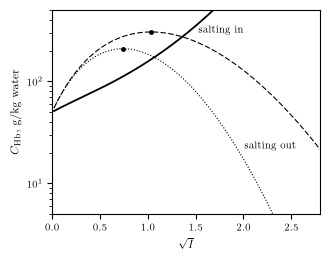

In [4]:
# Ionic strength contributed per mole of each salt, which is the second half of the
# marker argument and needs no data at all.
SALTS = {"NaCl": (1, 1, 1), "Na2SO4": (1, 2, 2), "MgSO4": (2, 2, 1)}
for name, (z_plus, z_minus, nu_plus) in SALTS.items():
    nu_minus = nu_plus * z_plus // z_minus
    I_per_m = 0.5 * (nu_plus * z_plus ** 2 + nu_minus * z_minus ** 2)
    print(f"  {name:8s}  |z+ z-| = {z_plus * z_minus}   I = {I_per_m:.0f} m")
print("\n  so at the same MOLALITY, MgSO4 delivers 4/3 the ionic strength of Na2SO4,")
print("  which is why its curve runs further to the right without salting out less.")

fig, ax = plt.subplots(figsize=(FIG_W, 2.7))
sqrtI = np.linspace(0.02, 2.8, 400)
I = sqrtI ** 2
# Illustrative parameter sets, chosen only to show the three SHAPES the text
# describes. They are NOT Green's fitted constants -- see the cell above.
shapes = [("salting in (NaCl-like)", 1.0, +0.55, 1.0, dict(lw=1.3)),
          ("weak salting out (MgSO4-like)", 1.0, -0.55, 4.0, dict(lw=0.8, ls=(0, (5, 2)))),
          ("strong salting out (Na2SO4-like)", 1.0, -1.05, 4.0,
           dict(lw=0.8, ls=(0, (1, 1.6))))]
for label, A, ks, zp, kw in shapes:
    ax.semilogy(sqrtI, 50.0 * solubility_ratio(I, A, ks, zp), "k", **kw)
    Imax = has_maximum(A, ks, zp)
    if Imax is not None:
        ax.plot([np.sqrt(Imax)], [50.0 * float(solubility_ratio(Imax, A, ks, zp))],
                "ko", ms=2.5)
ax.set_xlabel(r"$\sqrt{I}$", fontsize=8)
ax.set_ylabel(r"$C_{\rm Hb}$, g/kg water", fontsize=8)
ax.set_xlim(0, 2.8)
ax.set_ylim(5, 500)
ax.tick_params(labelsize=7)
ax.text(2.0, 300, "salting in", fontsize=7, ha="right")
ax.text(2.55, 22, "salting out", fontsize=7, ha="right")
fig.tight_layout()
print("\n  SHAPES ONLY -- the measured points and the fitted A, k_s are still to come")

## (b) Figure 15.2-3 — and Sec. 12.3 doing the work

$$\Delta_{s\to l}G(T)=\Delta_{s\to l}H(T_m)\left(1-\frac{T}{T_m}\right)
+\Delta_{s\to l}C_P\left(T-T_m-T\ln\frac{T}{T_m}\right),\qquad
\ln a=-\frac{\Delta_{s\to l}G(T)}{RT}$$

Rearranged, that is Eq. 12.3-2 exactly — the equation `thermo.sle.freezing_point` solves. The first
cell below checks that claim term by term rather than asserting it, and only then uses the ch12
solver on the ch15 data.

Hsieh *et al.*'s Table I, for the amorphous-to-solution transition:

| | Material A | Material B |
|---|---|---|
| $T_g$ | 393.4 K | 361 K |
| $T_m$ | 416 K | 483.6 K |
| $\Delta_{s\to l}H$ | 16 kJ/mol | 76 kJ/mol |
| $C_{P,a}$ (amorphous) | 1.0 kJ/(mol K) | 1.9 kJ/(mol K) |
| $C_{P,l}$ (liquid) | 0.7 kJ/(mol K) | 1.4 kJ/(mol K) |

In [5]:
MATERIALS = {
    #        Tg      Tm     dH (J/mol)  Cp_a    Cp_l   (kJ/(mol K))
    "A": dict(Tg=393.4, Tm=416.0, dH=16_000.0, Cp_a=1.0, Cp_l=0.7),
    "B": dict(Tg=361.0, Tm=483.6, dH=76_000.0, Cp_a=1.9, Cp_l=1.4),
}
for m in MATERIALS.values():
    m["dCp"] = (m["Cp_l"] - m["Cp_a"]) * 1000.0      # J/(mol K)


def dG_s_to_l(T, Tm, dH, dCp):
    """Eq. 15.2-16."""
    T = np.asarray(T, float)
    return dH * (1.0 - T / Tm) + dCp * (T - Tm - T * np.log(T / Tm))


# Eq. 15.2-16 divided by -RT must be thermo.sle's ln(x gamma). Check it.
T = np.linspace(300.0, 415.0, 41)
mA = MATERIALS["A"]
lhs = -dG_s_to_l(T, mA["Tm"], mA["dH"], mA["dCp"]) / (R_SLE * T)
rhs = ln_x_gamma(T, mA["Tm"], mA["dH"], mA["dCp"])
print(f"  max |Eq. 15.2-16 as ln a  -  thermo.sle.ln_x_gamma| = "
      f"{np.max(np.abs(lhs - rhs)):.3e}   (both on R = {R_SLE:.6f})")
assert np.max(np.abs(lhs - rhs)) < 1e-12
gap = np.max(np.abs(-dG_s_to_l(T, mA["Tm"], mA["dH"], mA["dCp"]) / (R * T) - rhs))
print(f"  the same comparison with the book's R = 8.314 differs by {gap:.1e} in ln a,")
print(f"  i.e. {100 * (R_SLE / R - 1):.3f} percent, which matters before reading a")
print(f"  third digit off any of the curves below")
print("  so Sec. 15.2(b) and Sec. 12.3 are the same equation, and the ch12 solver")
print("  can be used unchanged -- including its scan DOWNWARD from T_m, which is")
print("  what keeps it off the spurious low-temperature root that a large dCp creates")

  max |Eq. 15.2-16 as ln a  -  thermo.sle.ln_x_gamma| = 3.553e-15   (both on R = 8.314463)
  the same comparison with the book's R = 8.314 differs by 2.2e-04 in ln a,
  i.e. 0.006 percent, which matters before reading a
  third digit off any of the curves below
  so Sec. 15.2(b) and Sec. 12.3 are the same equation, and the ch12 solver
  can be used unchanged -- including its scan DOWNWARD from T_m, which is
  what keeps it off the spurious low-temperature root that a large dCp creates


In [6]:
rows = []
for name, m in MATERIALS.items():
    for a in (1.0, 0.9, 0.8, 0.73, 0.5, 0.3, 0.1):
        T = freezing_point(a, m["Tm"], m["dH"], m["dCp"], T_min=150.0)
        rows.append((name, a, T, T - m["Tg"]))
print(pd.DataFrame(rows, columns=["material", "activity a", "T_precip, K",
                                  "T_precip - Tg, K"])
      .to_string(index=False, float_format=lambda v: f"{v:.4g}"))

A_FLOOR = 0.005
for name, m in MATERIALS.items():
    f = lambda a: freezing_point(a, m["Tm"], m["dH"], m["dCp"], T_min=150.0) - m["Tg"]
    if f(A_FLOOR) > 0:
        print(f"\n  material {name}: NO crossing -- the precipitation temperature is "
              f"still {f(A_FLOOR) + m['Tg']:.0f} K")
        print(f"  at a = {A_FLOOR}, {f(A_FLOOR):.0f} K above its glass transition. There is no "
              f"glass-transition\n  limit on how far this one can be diluted.")
    else:
        a_star = brentq(f, A_FLOOR, 1.0 - 1e-9)
        print(f"\n  material {name}: the precipitation curve crosses its own glass "
              f"transition at a = {a_star:.3f}")
print("\n  Sec. 15.2(b) says of material A: 'it may be difficult to process this")
print("  substance in solution at mole fractions (activities) of less than 0.73'.")
print("  That is where T_precip falls below T_g -- the melt cannot relax, so what")
print("  comes out is a glass. The 0.73 is a GLASS TRANSITION, not a slope.")

material  activity a  T_precip, K  T_precip - Tg, K
       A           1          416              22.6
       A         0.9        407.4             14.02
       A         0.8        399.4             5.965
       A        0.73        393.9            0.4759
       A         0.5        375.6            -17.83
       A         0.3        357.2            -36.24
       A         0.1        328.9            -64.48
       B           1        483.6             122.6
       B         0.9        480.9             119.9
       B         0.8        478.1             117.1
       B        0.73        475.9             114.9
       B         0.5        467.3             106.3
       B         0.3        456.9             95.89
       B         0.1        437.5             76.52

  material A: the precipitation curve crosses its own glass transition at a = 0.724

  material B: NO crossing -- the precipitation temperature is still 398 K
  at a = 0.005, 37 K above its glass transition. There is no

  wrote pdf/c15f005.pdf  (Figure 15.2-3, both panels)

  Sec. 15.2(b) on material B: 'for mole fractions above 0.1, precipitation is
  unlikely as long as the temperature is above 400 K'.
  computed: at a = 0.1, T_precip = 437.5 K
  and T_precip = 400 K at a = 0.0061


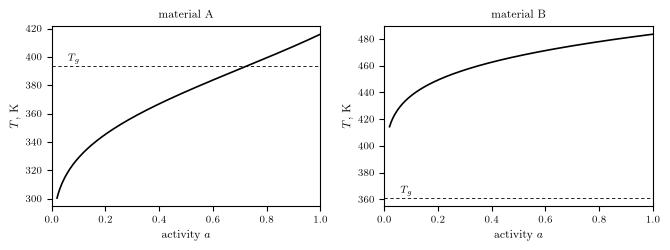

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(2 * FIG_W, 2.6))
for ax, (name, m) in zip(axes, MATERIALS.items()):
    a = np.linspace(0.02, 1.0, 200)
    T = np.array([freezing_point(x, m["Tm"], m["dH"], m["dCp"], T_min=150.0) for x in a])
    ax.plot(a, T, "k", lw=1.2)
    ax.axhline(m["Tg"], color="k", lw=0.6, ls=(0, (4, 3)))
    ax.annotate(r"$T_g$", xy=(0.06, m["Tg"]), xytext=(0.06, m["Tg"] + 4), fontsize=7)
    ax.set_xlabel(r"activity $a$", fontsize=8)
    ax.set_ylabel(r"$T$, K", fontsize=8)
    ax.set_xlim(0, 1)
    ax.tick_params(labelsize=7)
    ax.set_title(f"material {name}", fontsize=8)
fig.tight_layout()
fig.savefig("pdf/c15f005.pdf", dpi=300, bbox_inches="tight")
print("  wrote pdf/c15f005.pdf  (Figure 15.2-3, both panels)")

print("\n  Sec. 15.2(b) on material B: 'for mole fractions above 0.1, precipitation is")
print("  unlikely as long as the temperature is above 400 K'.")
mB = MATERIALS["B"]
print(f"  computed: at a = 0.1, T_precip = "
      f"{freezing_point(0.1, mB['Tm'], mB['dH'], mB['dCp'], T_min=150.0):.1f} K")
a01 = brentq(lambda a: freezing_point(a, mB["Tm"], mB["dH"], mB["dCp"], T_min=150.0)
             - 400.0, 0.005, 1.0 - 1e-9)
print(f"  and T_precip = 400 K at a = {a01:.4f}")

## Why the two materials behave so differently

The section attributes it to material B's "much higher heat of fusion", and that is most of the
story but not all of it — B's $T_m$ is 68 K higher as well, and the freezing-point depression at
fixed activity scales as $RT_m^2/\Delta H$. Splitting the two effects is one line of arithmetic.

In [8]:
print(f"  {'':12s}  {'dH, kJ/mol':>11s}  {'T_m, K':>7s}  {'R Tm^2/dH, K':>13s}")
for name, m in MATERIALS.items():
    print(f"  material {name:2s}   {m['dH'] / 1000:11.0f}  {m['Tm']:7.1f}  "
          f"{R * m['Tm'] ** 2 / m['dH']:13.1f}")
print("\n  the dilute-limit depression per unit mole fraction of solute (Eq. 12.3-5).")
print("  B's is smaller by a factor of", end=" ")
print(f"{(R * MATERIALS['A']['Tm'] ** 2 / MATERIALS['A']['dH']) / (R * MATERIALS['B']['Tm'] ** 2 / MATERIALS['B']['dH']):.2f}, of which")
ratio_dH = MATERIALS["B"]["dH"] / MATERIALS["A"]["dH"]
ratio_Tm = (MATERIALS["B"]["Tm"] / MATERIALS["A"]["Tm"]) ** 2
print(f"  the enthalpy contributes {ratio_dH:.2f} and T_m^2 pushes back by {ratio_Tm:.2f}.")
print("  So the heat of fusion is the reason, and the higher melting point works")
print("  against it, which is the half of the answer that is easy to lose.")

                 dH, kJ/mol   T_m, K   R Tm^2/dH, K
  material A             16    416.0           89.9
  material B             76    483.6           25.6

  the dilute-limit depression per unit mole fraction of solute (Eq. 12.3-5).
  B's is smaller by a factor of 3.51, of which
  the enthalpy contributes 4.75 and T_m^2 pushes back by 1.35.
  So the heat of fusion is the reason, and the higher melting point works
  against it, which is the half of the answer that is easy to lose.


## What came out of this

| target | here | printed |
|---|---|---|
| Fig. 15.2-1, the second sulfate's marker | **triangles** = MgSO$_4$ | "(squares)" twice |
| the two arguments in the text | they **agree** | read as competing |
| Eq. 15.2-16 vs. `thermo.sle.ln_x_gamma` | identical to $10^{-12}$ | Sec. 12.3 not cited |
| material A, $T_{\rm precip}$ at $a=0.73$ | 393.9 K | — |
| material A, $T_g$ | 393.4 K | — |
| material A, where $T_{\rm precip}=T_g$ | $a = 0.724$ | "less than 0.73" |
| material B, $T_{\rm precip}$ at $a=0.1$ | 437.5 K | "above 400 K" |
| material B, crossing with its own $T_g$ | **none** down to $a=0.005$ | — |

The substantive find is in the last block. Sec. 15.2(b) says material A becomes hard to process
below $a=0.73$ "because the precipitation temperature drops sharply with further dilution", but the
curve has no sharp feature there at all — its slope is smooth and about $-83$ K per unit activity
through the whole region. What happens at 0.73 is that **the precipitation temperature crosses the
material's own glass transition**, 393.4 K, which is in the same table. Below that crossing what
comes out of solution cannot relax to a crystal, and that is a formulation problem of a different
kind. The number 0.73 is right; the reason given for it is not the one in the data.

Two items are still open, both data rather than arithmetic: Green's carboxyhemoglobin solubilities
with their fitted $A$ and $k_s$ (Figure 15.2-1), and Hsieh *et al.*'s DSC traces (Figure 15.2-2),
which are instrument output and cannot be recomputed from Table I at all.

## Your turn

1. Eq. 15.2-11 has a maximum only when $k_s<0$. Derive the condition on $A$ and $k_s$ for the
   maximum to fall inside an experimentally reachable ionic strength, say $I<6$ M, and sketch the
   region in the $(A,k_s)$ plane. Where in that region does a 2:2 salt sit relative to a 1:1 salt
   with the same dielectric increment?
2. The section gives $\delta$ in Debye/mol for methanol ($-1.4$), acetone ($-3.2$), sucrose
   ($-7.5$), urea ($+2.7$) and glycine ($+22.6$), and reports that l-asparagine's solubility goes
   from 0.184 to 0.211 to 0.247 mol/L in 0, 1.0 and 2.80 M glycine. Fit $\beta$ from those three
   points, then predict the asparagine solubility in 1 M urea. How confident should you be, and
   what would you measure to check?
3. Redo Figure 15.2-3 for material A with $\Delta C_P$ set to zero. How far does the $a = 0.1$
   precipitation temperature move, and does the crossing with $T_g$ move enough to change the
   section's conclusion? Then say which of the two — $\Delta H$ or $\Delta C_P$ — the conclusion is
   actually sensitive to.
4. Material A's precipitation curve crosses its glass transition at $a=0.724$; material B's never
   crosses at all over the plotted range. Find the general condition, in terms of $T_g/T_m$ and
   $\Delta H/RT_m$, that separates the two cases — and then say which of B's four Table I entries
   you would have to change, and by how much, to give it a crossing at $a=0.5$.
5. The Hofmeister series orders anions F$^-\sim$SO$_4^{2-}>$ HPO$_4^{2-}>$ acetate $>$ Cl$^-\dots$
   Using Eq. 15.2-11, decide whether that ordering is a statement about $k_s$, about $|z_+z_-|$, or
   about both — and construct a case where two salts with the same $|z_+z_-|$ sit at opposite ends
   of the series.
6. Sec. 15.2(a) drops the entropic and dispersion contributions to $\ln\gamma_P$ and keeps only the
   electrostatic ones, saying the latter dominate "except near the isoelectric point". Take the
   albumin/lysozyme pIs from the end of Sec. 15.1 and estimate at what pH offset from the pI the
   dropped terms would matter. What measurement would tell you whether the estimate is right?